In [3]:
import pandas as pd
import json
import os


# Function to read a JSON file and return a DataFrame with grain_contour_image_path
def read_json_to_dataframe(file_path, folder_path):
    with open(file_path, 'r') as file:
        data = json.load(file)
    
    # Extract the filename without extension
    base_filename = os.path.splitext(data['file_name']['0'])[0]
    
    # Prepare a list to store data for each contour
    records = []
    
    # Iterate over each contour
    for index in data['contour']:
        record = {key: data[key][index] for key in data}
        # Create the grain_contour_image_path with folder path
        contour_name = f"{base_filename}_contour_{index}.jpg"
        record['grain_contour_image_path'] = os.path.join(folder_path, contour_name)
        records.append(record)
    
    # Convert the list of records to a DataFrame
    return pd.DataFrame(records)
# Directory containing JSON files
json_directory = '/projects/OLIVINE/data/test_folder_json_output'
folder_path = '/projects/OLIVINE/data/test_folder_save_grain_img'

# List all JSON files in the directory
json_files = [f for f in os.listdir(json_directory) if f.endswith('.json')]

# Initialize an empty DataFrame
combined_df = pd.DataFrame()

# Loop through each JSON file and append to the DataFrame
for json_file in json_files:
    file_path = os.path.join(json_directory, json_file)
    df = read_json_to_dataframe(file_path, folder_path)
    combined_df = pd.concat([combined_df, df], ignore_index=True)

# Save the combined DataFrame to a CSV file
combined_df.to_csv('combined_data.csv', index=False)

In [4]:
combined_df.head()

,file_name,width,height,contour,touch_edge,area,sphericity,feret_max,feret_min,centroid,grain_contour_image_path
0,temp-11262024112607-580.jpg,1616,1240,"[[[1264, 1208]], [[1259, 1209]], [[1232, 1228]...",True,2025.5,0.185216,118.000000,31.000000,"[1274, 1227]",/projects/OLIVINE/data/test_folder_save_grain_...
1,temp-11262024112607-580.jpg,1616,1240,"[[[1187, 818]], [[1170, 827]], [[1164, 844]], ...",False,12038.0,0.692989,148.222805,107.077008,"[1228, 869]",/projects/OLIVINE/data/test_folder_save_grain_...
2,temp-11262024112607-580.jpg,1616,1240,"[[[1046, 759]], [[1029, 797]], [[1031, 817]], ...",False,9658.5,0.554120,148.973152,96.070251,"[1078, 822]",/projects/OLIVINE/data/test_folder_save_grain_...
3,temp-11262024112607-580.jpg,1616,1240,"[[[585, 459]], [[542, 493]], [[486, 566]], [[4...",False,133418.0,0.699600,492.741311,356.773768,"[657, 699]",/projects/OLIVINE/data/test_folder_save_grain_...
4,temp-11262024112607-580.jpg,1616,1240,"[[[1315, 232]], [[1278, 250]], [[1264, 262]], ...",False,28613.5,0.576964,251.284699,160.508361,"[1290, 338]",/projects/OLIVINE/data/test_folder_save_grain_...


In [6]:
combined_df['touch_edge'] = combined_df['touch_edge'].astype(int)

In [7]:
rows_with_nan = combined_df.isna().any(axis=1)

In [8]:
combined_df_dropped = combined_df.dropna()

In [9]:
combined_df_dropped.head()

,file_name,width,height,contour,touch_edge,area,sphericity,feret_max,feret_min,centroid,grain_contour_image_path
0,temp-11262024112607-580.jpg,1616,1240,"[[[1264, 1208]], [[1259, 1209]], [[1232, 1228]...",1,2025.5,0.185216,118.000000,31.000000,"[1274, 1227]",/projects/OLIVINE/data/test_folder_save_grain_...
1,temp-11262024112607-580.jpg,1616,1240,"[[[1187, 818]], [[1170, 827]], [[1164, 844]], ...",0,12038.0,0.692989,148.222805,107.077008,"[1228, 869]",/projects/OLIVINE/data/test_folder_save_grain_...
2,temp-11262024112607-580.jpg,1616,1240,"[[[1046, 759]], [[1029, 797]], [[1031, 817]], ...",0,9658.5,0.554120,148.973152,96.070251,"[1078, 822]",/projects/OLIVINE/data/test_folder_save_grain_...
3,temp-11262024112607-580.jpg,1616,1240,"[[[585, 459]], [[542, 493]], [[486, 566]], [[4...",0,133418.0,0.699600,492.741311,356.773768,"[657, 699]",/projects/OLIVINE/data/test_folder_save_grain_...
4,temp-11262024112607-580.jpg,1616,1240,"[[[1315, 232]], [[1278, 250]], [[1264, 262]], ...",0,28613.5,0.576964,251.284699,160.508361,"[1290, 338]",/projects/OLIVINE/data/test_folder_save_grain_...


In [ ]:
selected_columns = ['touch_edge', 'area', 'sphericity', 'feret_max', 'feret_min']
selected_df = combined_df_dropped[selected_columns]
selected_df.head()

,touch_edge,area,sphericity,feret_max,feret_min
0,1,2025.5,0.185216,118.000000,31.000000
1,0,12038.0,0.692989,148.222805,107.077008
2,0,9658.5,0.554120,148.973152,96.070251
3,0,133418.0,0.699600,492.741311,356.773768
4,0,28613.5,0.576964,251.284699,160.508361


In [15]:
df_true = selected_df[selected_df['touch_edge'] == 0]

In [16]:
contour_image_list = combined_df_dropped['grain_contour_image_path']

In [17]:
numpy_array = df_true.to_numpy()
numpy_array.shape

(1207, 5)

In [14]:
from sklearn.manifold import TSNE

ModuleNotFoundError: No module named 'sklearn'

In [23]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(numpy_array)

print('Explained variation per principal component: {}'.format(pca.explained_variance_ratio_))


Explained variation per principal component: [9.99995424e-01 3.13969067e-06]


In [24]:
import matplotlib.pyplot as plt

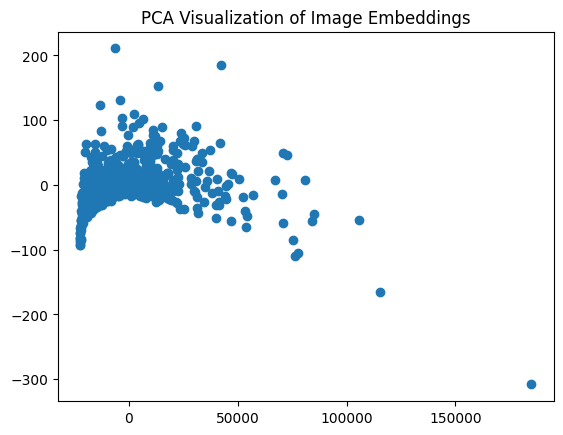

In [25]:
fig = plt.figure()
ax = fig.add_subplot(111)
ax.scatter(pca_result[:, 0], pca_result[:, 1])
plt.title("PCA Visualization of Image Embeddings")
plt.show()

In [26]:
import numpy as np
from PIL import Image
%matplotlib inline
import matplotlib.pyplot
from matplotlib.pyplot import imshow

In [27]:
tx, ty = pca_result[:,0], pca_result[:,1]
tx = (tx-np.min(tx)) / (np.max(tx) - np.min(tx))
ty = (ty-np.min(ty)) / (np.max(ty) - np.min(ty))

In [28]:
contour_image_list = combined_df_dropped['grain_contour_image_path']

No image found: /projects/OLIVINE/data/test_folder_save_grain_img/temp-11262024112557-469_contour_0.jpg
No image found: /projects/OLIVINE/data/test_folder_save_grain_img/temp-11262024112549-400_contour_4.jpg
No image found: /projects/OLIVINE/data/test_folder_save_grain_img/temp-11262024112522-91_contour_0.jpg
No image found: /projects/OLIVINE/data/test_folder_save_grain_img/temp-11262024112543-349_contour_0.jpg


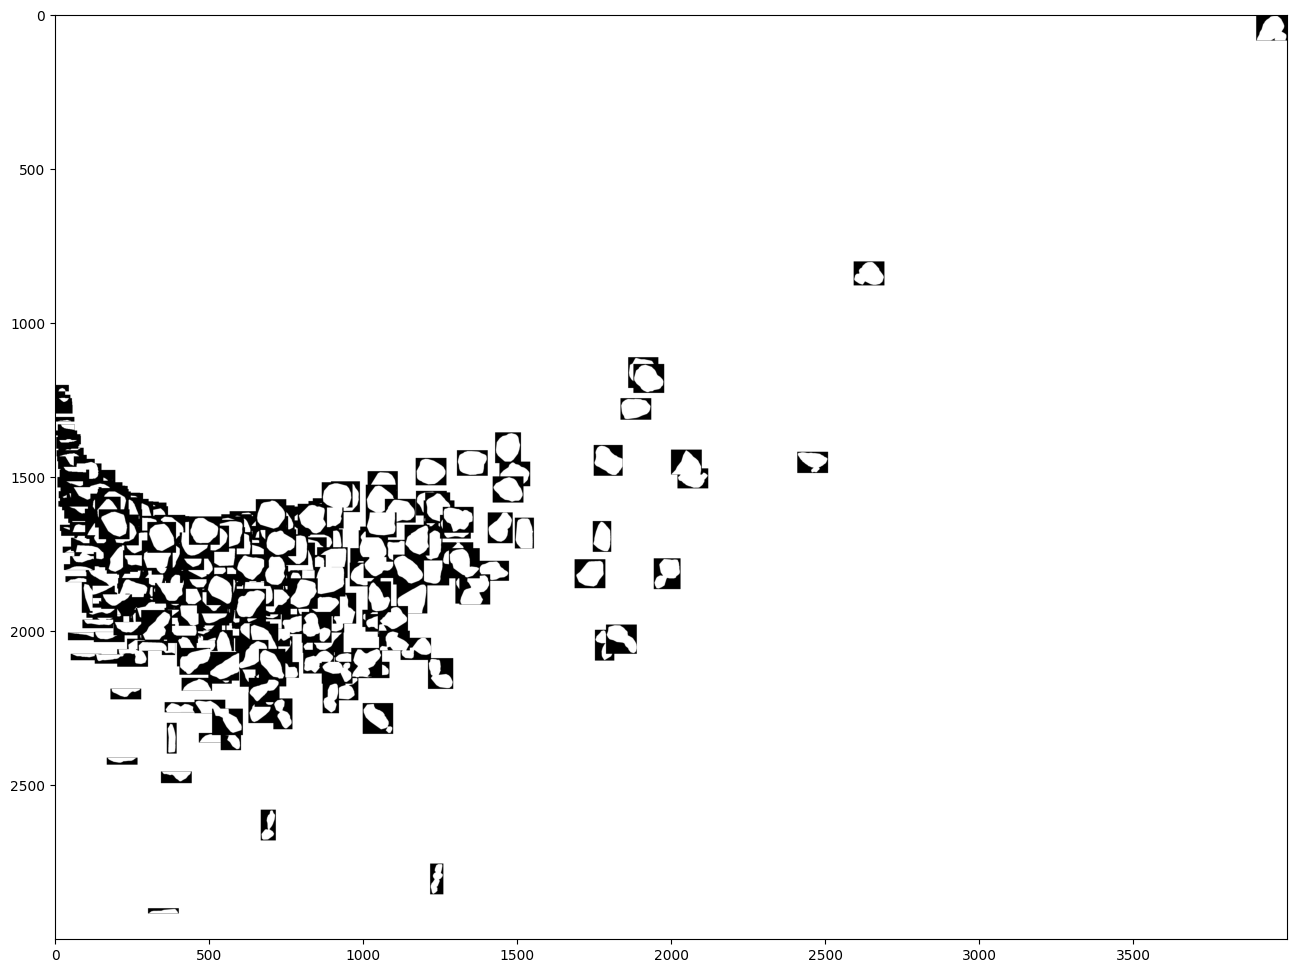

In [29]:
width = 4000
height = 3000
max_dim = 100

full_image = Image.new('RGBA', (width, height))
for img, x, y in zip(contour_image_list, tx, ty):
    try: 
        tile = Image.open(img)
        rs = max(1, tile.width/max_dim, tile.height/max_dim)
        tile = tile.resize((int(tile.width/rs), int(tile.height/rs)), Image.LANCZOS)
        full_image.paste(tile, (int((width-max_dim)*x), int((height-max_dim)*y)), mask=tile.convert('RGBA'))
    except:
        print(f'No image found: {img}')

matplotlib.pyplot.figure(figsize = (16,12))
imshow(full_image)

In [30]:
# Normalize the embeddings
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
normalized_embeddings = scaler.fit_transform(numpy_array)

In [31]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(normalized_embeddings)

print('Explained variation per principal component: {}'.format(pca.explained_variance_ratio_))

Explained variation per principal component: [0.59539071 0.29086643]


In [32]:
tx, ty = pca_result[:,0], pca_result[:,1]
tx = (tx-np.min(tx)) / (np.max(tx) - np.min(tx))
ty = (ty-np.min(ty)) / (np.max(ty) - np.min(ty))

No image found: /projects/OLIVINE/data/test_folder_save_grain_img/temp-11262024112557-469_contour_0.jpg
No image found: /projects/OLIVINE/data/test_folder_save_grain_img/temp-11262024112549-400_contour_4.jpg
No image found: /projects/OLIVINE/data/test_folder_save_grain_img/temp-11262024112522-91_contour_0.jpg
No image found: /projects/OLIVINE/data/test_folder_save_grain_img/temp-11262024112543-349_contour_0.jpg


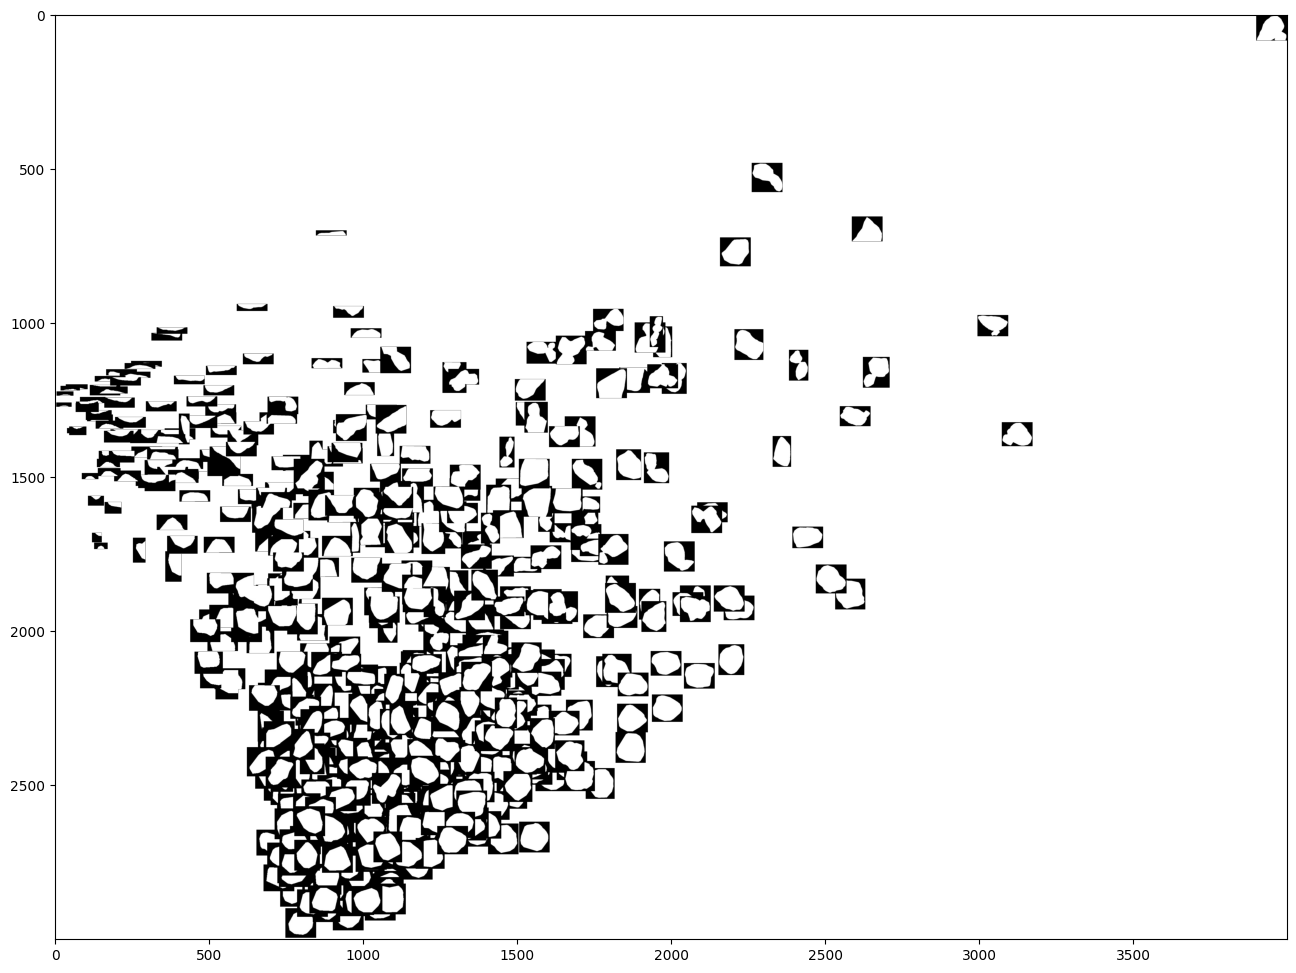

In [33]:
width = 4000
height = 3000
max_dim = 100

full_image = Image.new('RGBA', (width, height))
for img, x, y in zip(contour_image_list, tx, ty):
    try: 
        tile = Image.open(img)
        rs = max(1, tile.width/max_dim, tile.height/max_dim)
        tile = tile.resize((int(tile.width/rs), int(tile.height/rs)), Image.LANCZOS)
        full_image.paste(tile, (int((width-max_dim)*x), int((height-max_dim)*y)), mask=tile.convert('RGBA'))
    except:
        print(f'No image found: {img}')

matplotlib.pyplot.figure(figsize = (16,12))
imshow(full_image)

In [36]:
tsne = TSNE(n_components=2, learning_rate=150, perplexity=50, verbose=2).fit_transform(numpy_array)

[t-SNE] Computing 151 nearest neighbors...
[t-SNE] Indexed 652 samples in 0.001s...
[t-SNE] Computed neighbors for 652 samples in 0.013s...
[t-SNE] Computed conditional probabilities for sample 652 / 652
[t-SNE] Mean sigma: 991.527730
[t-SNE] Computed conditional probabilities in 0.064s
[t-SNE] Iteration 50: error = 50.2056198, gradient norm = 0.0921622 (50 iterations in 0.104s)
[t-SNE] Iteration 100: error = 45.1767807, gradient norm = 0.0780367 (50 iterations in 0.087s)
[t-SNE] Iteration 150: error = 44.3706818, gradient norm = 0.0650522 (50 iterations in 0.077s)
[t-SNE] Iteration 200: error = 44.1422310, gradient norm = 0.0627278 (50 iterations in 0.076s)
[t-SNE] Iteration 250: error = 44.0997467, gradient norm = 0.0684324 (50 iterations in 0.079s)
[t-SNE] KL divergence after 250 iterations with early exaggeration: 44.099747
[t-SNE] Iteration 300: error = 0.1633900, gradient norm = 0.0027502 (50 iterations in 0.071s)
[t-SNE] Iteration 350: error = 0.1474778, gradient norm = 0.001614

In [37]:
tx, ty = tsne[:,0], tsne[:,1]
tx = (tx-np.min(tx)) / (np.max(tx) - np.min(tx))
ty = (ty-np.min(ty)) / (np.max(ty) - np.min(ty))

No image found: /projects/OLIVINE/data/test_folder_save_grain_img/temp-11262024112557-469_contour_0.jpg
No image found: /projects/OLIVINE/data/test_folder_save_grain_img/temp-11262024112549-400_contour_4.jpg
No image found: /projects/OLIVINE/data/test_folder_save_grain_img/temp-11262024112522-91_contour_0.jpg
No image found: /projects/OLIVINE/data/test_folder_save_grain_img/temp-11262024112543-349_contour_0.jpg


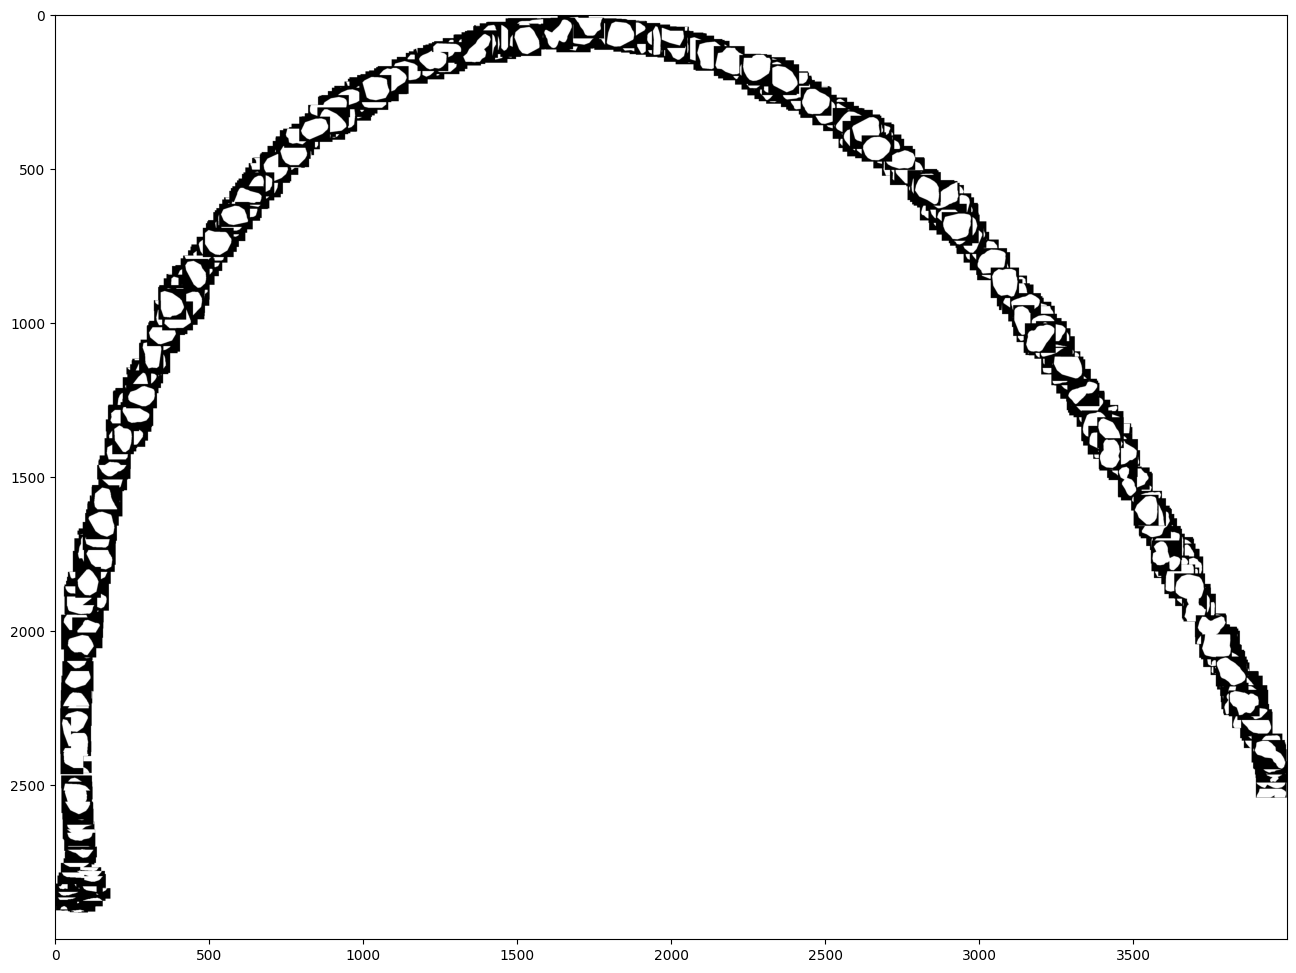

In [38]:
width = 4000
height = 3000
max_dim = 100

full_image = Image.new('RGBA', (width, height))
for img, x, y in zip(contour_image_list, tx, ty):
    try: 
        tile = Image.open(img)
        rs = max(1, tile.width/max_dim, tile.height/max_dim)
        tile = tile.resize((int(tile.width/rs), int(tile.height/rs)), Image.LANCZOS)
        full_image.paste(tile, (int((width-max_dim)*x), int((height-max_dim)*y)), mask=tile.convert('RGBA'))
    except:
        print(f'No image found: {img}')

matplotlib.pyplot.figure(figsize = (16,12))
imshow(full_image)

In [48]:
tsne = TSNE(n_components=2, learning_rate=150, perplexity=5, verbose=2).fit_transform(normalized_embeddings)

[t-SNE] Computing 16 nearest neighbors...
[t-SNE] Indexed 652 samples in 0.001s...
[t-SNE] Computed neighbors for 652 samples in 0.005s...
[t-SNE] Computed conditional probabilities for sample 652 / 652
[t-SNE] Mean sigma: 0.129320
[t-SNE] Computed conditional probabilities in 0.006s
[t-SNE] Iteration 50: error = 77.7888794, gradient norm = 0.2587208 (50 iterations in 0.073s)
[t-SNE] Iteration 100: error = 69.4306641, gradient norm = 0.2438830 (50 iterations in 0.068s)
[t-SNE] Iteration 150: error = 66.1665268, gradient norm = 0.2494573 (50 iterations in 0.067s)
[t-SNE] Iteration 200: error = 63.8414536, gradient norm = 0.2252200 (50 iterations in 0.063s)
[t-SNE] Iteration 250: error = 63.1529388, gradient norm = 0.2271203 (50 iterations in 0.061s)
[t-SNE] KL divergence after 250 iterations with early exaggeration: 63.152939
[t-SNE] Iteration 300: error = 0.9499406, gradient norm = 0.0103002 (50 iterations in 0.060s)
[t-SNE] Iteration 350: error = 0.6720486, gradient norm = 0.0061984 (

In [49]:
tx, ty = tsne[:,0], tsne[:,1]
tx = (tx-np.min(tx)) / (np.max(tx) - np.min(tx))
ty = (ty-np.min(ty)) / (np.max(ty) - np.min(ty))

No image found: /projects/OLIVINE/data/test_folder_save_grain_img/temp-11262024112557-469_contour_0.jpg
No image found: /projects/OLIVINE/data/test_folder_save_grain_img/temp-11262024112549-400_contour_4.jpg
No image found: /projects/OLIVINE/data/test_folder_save_grain_img/temp-11262024112522-91_contour_0.jpg
No image found: /projects/OLIVINE/data/test_folder_save_grain_img/temp-11262024112543-349_contour_0.jpg


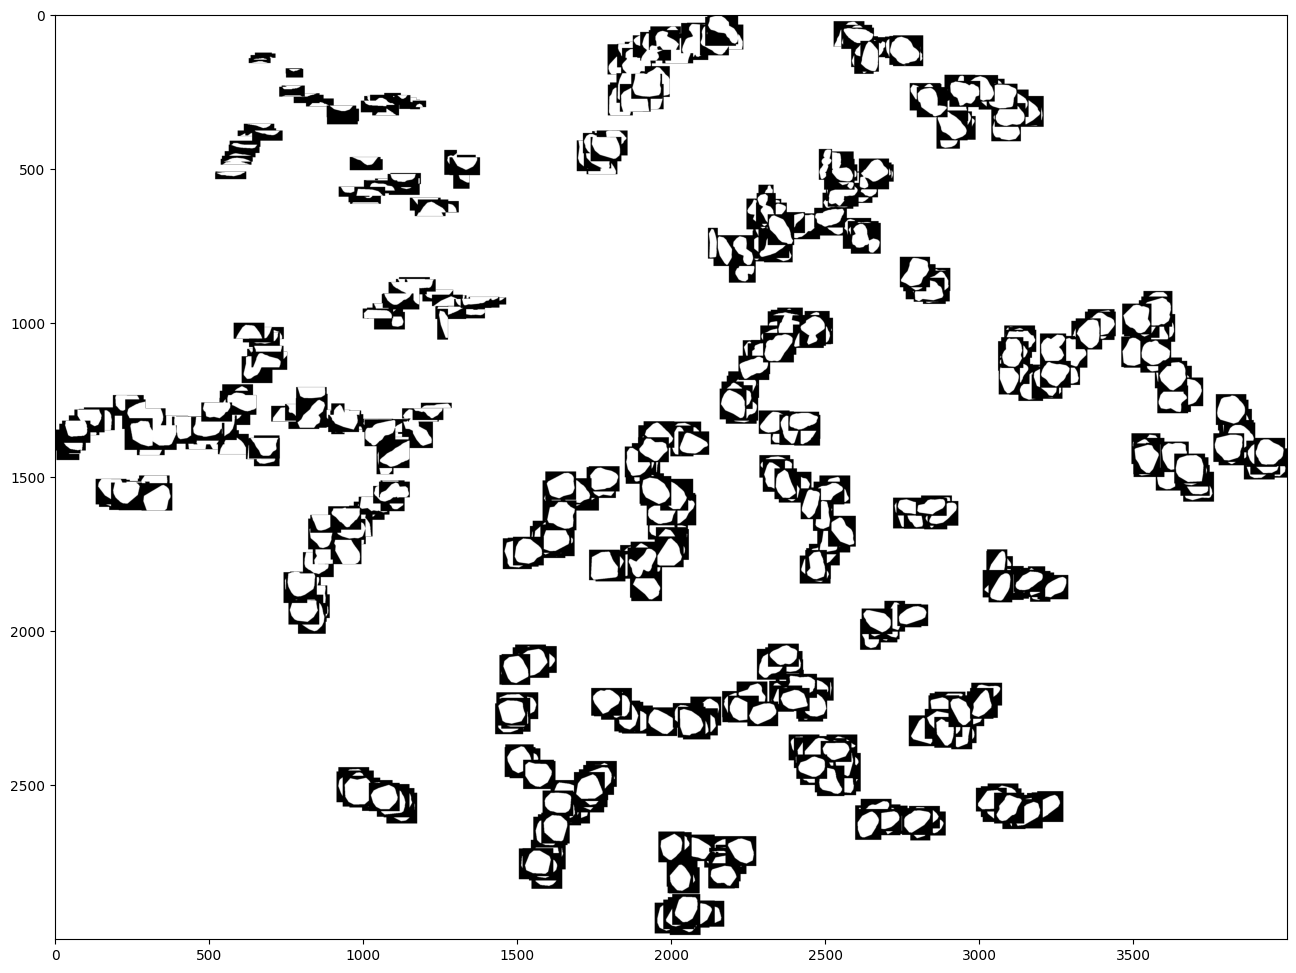

In [50]:
width = 4000
height = 3000
max_dim = 100

full_image = Image.new('RGBA', (width, height))
for img, x, y in zip(contour_image_list, tx, ty):
    try: 
        tile = Image.open(img)
        rs = max(1, tile.width/max_dim, tile.height/max_dim)
        tile = tile.resize((int(tile.width/rs), int(tile.height/rs)), Image.LANCZOS)
        full_image.paste(tile, (int((width-max_dim)*x), int((height-max_dim)*y)), mask=tile.convert('RGBA'))
    except:
        print(f'No image found: {img}')

matplotlib.pyplot.figure(figsize = (16,12))
imshow(full_image)

In [52]:
from sklearn.decomposition import PCA
pca = PCA(n_components=5)
pca_result = pca.fit_transform(normalized_embeddings)

print('Explained variation per principal component: {}'.format(pca.explained_variance_ratio_))

Explained variation per principal component: [0.59539071 0.29086643 0.09361127 0.01416432 0.00596727]


In [53]:
tsne = TSNE(n_components=2, learning_rate=150, perplexity=5, verbose=2).fit_transform(pca_result)

[t-SNE] Computing 16 nearest neighbors...
[t-SNE] Indexed 652 samples in 0.001s...
[t-SNE] Computed neighbors for 652 samples in 0.004s...
[t-SNE] Computed conditional probabilities for sample 652 / 652
[t-SNE] Mean sigma: 0.129320
[t-SNE] Computed conditional probabilities in 0.006s
[t-SNE] Iteration 50: error = 77.7888794, gradient norm = 0.2587208 (50 iterations in 0.070s)
[t-SNE] Iteration 100: error = 69.4306717, gradient norm = 0.2438830 (50 iterations in 0.066s)
[t-SNE] Iteration 150: error = 66.1665268, gradient norm = 0.2494573 (50 iterations in 0.063s)
[t-SNE] Iteration 200: error = 63.8414536, gradient norm = 0.2252200 (50 iterations in 0.061s)
[t-SNE] Iteration 250: error = 63.1529388, gradient norm = 0.2271203 (50 iterations in 0.059s)
[t-SNE] KL divergence after 250 iterations with early exaggeration: 63.152939
[t-SNE] Iteration 300: error = 0.9499406, gradient norm = 0.0103002 (50 iterations in 0.058s)
[t-SNE] Iteration 350: error = 0.6720486, gradient norm = 0.0061984 (

In [ ]:
tx, ty = tsne[:,0], tsne[:,1]
tx = (tx-np.min(tx)) / (np.max(tx) - np.min(tx))
ty = (ty-np.min(ty)) / (np.max(ty) - np.min(ty))
width = 4000
height = 3000
max_dim = 100

full_image = Image.new('RGBA', (width, height))
for img, x, y in zip(contour_image_list, tx, ty):
    try: 
        tile = Image.open(img)
        rs = max(1, tile.width/max_dim, tile.height/max_dim)
        tile = tile.resize((int(tile.width/rs), int(tile.height/rs)), Image.LANCZOS)
        full_image.paste(tile, (int((width-max_dim)*x), int((height-max_dim)*y)), mask=tile.convert('RGBA'))
    except:
        print(f'No image found: {img}')

matplotlib.pyplot.figure(figsize = (16,12))
imshow(full_image)

No image found: /projects/OLIVINE/data/test_folder_save_grain_img/temp-11262024112557-469_contour_0.jpg
No image found: /projects/OLIVINE/data/test_folder_save_grain_img/temp-11262024112549-400_contour_4.jpg
No image found: /projects/OLIVINE/data/test_folder_save_grain_img/temp-11262024112522-91_contour_0.jpg
No image found: /projects/OLIVINE/data/test_folder_save_grain_img/temp-11262024112543-349_contour_0.jpg
